
Import Libraries


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

Load Dataset

In [3]:
df = pd.read_csv("H1_cleaned_feature_engineering.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'H1_cleaned_feature_engineering.csv'

Define Features & Target

In [1]:
target = "iscanceled"

X = df.drop(columns=[target])
y = df[target]

NameError: name 'df' is not defined

Encode Categorical Variables

In [14]:
X = pd.get_dummies(X, drop_first=True)

Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Feature Scaling

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train Logistic Regression Model

In [17]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Predictions

In [18]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

Evaluation Metrics

In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("ROC-AUC:", roc_auc)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
ROC-AUC: 1.0

Confusion Matrix:
 [[5788    0]
 [   0 2224]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5788
           1       1.00      1.00      1.00      2224

    accuracy                           1.00      8012
   macro avg       1.00      1.00      1.00      8012
weighted avg       1.00      1.00      1.00      8012



ROC Curve

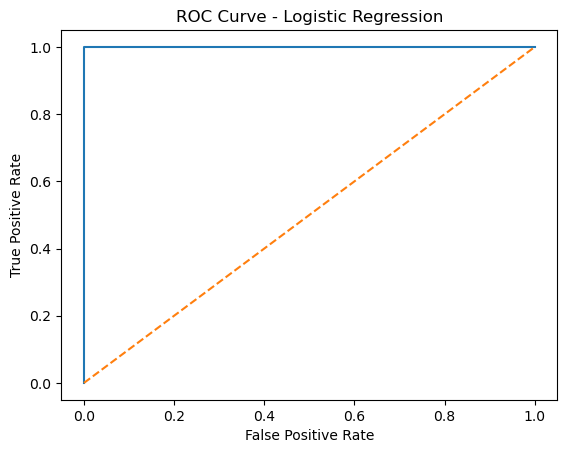

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.show()

Train Decision Tree

In [21]:
dt_model = DecisionTreeClassifier(
    max_depth=5,         # control overfitting
    min_samples_split=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

Predictions

In [22]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

Evaluation Metrics

In [23]:
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
roc_auc = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("ROC-AUC:", roc_auc)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
ROC-AUC: 1.0

Confusion Matrix:
 [[5788    0]
 [   0 2224]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5788
           1       1.00      1.00      1.00      2224

    accuracy                           1.00      8012
   macro avg       1.00      1.00      1.00      8012
weighted avg       1.00      1.00      1.00      8012



ROC Curve

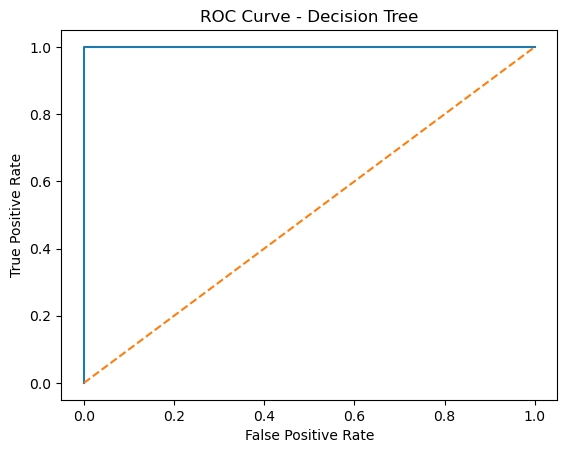

In [24]:
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.show()